<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Hospital_Beds_Management_Dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d jaderz/hospital-beds-management

# Unziping the downloaded file
!unzip hospital-beds-management.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/jaderz/hospital-beds-management
License(s): CC0-1.0
hospital-beds-management.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  hospital-beds-management.zip
  inflating: patients.csv            
  inflating: services_weekly.csv     
  inflating: staff.csv               
  inflating: staff_schedule.csv      


In [43]:
df = pd.read_csv('staff_schedule.csv')
df.head(11)

,week,staff_id,staff_name,role,service,present
0,1,STF-b77cdc60,Allison Hill,doctor,emergency,1
1,2,STF-b77cdc60,Allison Hill,doctor,emergency,1
2,3,STF-b77cdc60,Allison Hill,doctor,emergency,0
3,4,STF-b77cdc60,Allison Hill,doctor,emergency,1
4,5,STF-b77cdc60,Allison Hill,doctor,emergency,1
5,6,STF-b77cdc60,Allison Hill,doctor,emergency,0
6,7,STF-b77cdc60,Allison Hill,doctor,emergency,1
7,8,STF-b77cdc60,Allison Hill,doctor,emergency,1
8,9,STF-b77cdc60,Allison Hill,doctor,emergency,0
9,10,STF-b77cdc60,Allison Hill,doctor,emergency,1


In [44]:
df.tail(11)

,week,staff_id,staff_name,role,service,present
6541,42,STF-302eb752,Erin Edwards,nursing_assistant,ICU,0
6542,43,STF-302eb752,Erin Edwards,nursing_assistant,ICU,0
6543,44,STF-302eb752,Erin Edwards,nursing_assistant,ICU,1
6544,45,STF-302eb752,Erin Edwards,nursing_assistant,ICU,0
6545,46,STF-302eb752,Erin Edwards,nursing_assistant,ICU,0
6546,47,STF-302eb752,Erin Edwards,nursing_assistant,ICU,1
6547,48,STF-302eb752,Erin Edwards,nursing_assistant,ICU,0
6548,49,STF-302eb752,Erin Edwards,nursing_assistant,ICU,1
6549,50,STF-302eb752,Erin Edwards,nursing_assistant,ICU,1
6550,51,STF-302eb752,Erin Edwards,nursing_assistant,ICU,0


In [45]:
df.shape

(6552, 6)

In [46]:
df.columns

Index(['week', 'staff_id', 'staff_name', 'role', 'service', 'present'], dtype='object')

In [47]:
df.dtypes

,0
week,int64
staff_id,object
staff_name,object
role,object
service,object
present,int64


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552 entries, 0 to 6551
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   week        6552 non-null   int64 
 1   staff_id    6552 non-null   object
 2   staff_name  6552 non-null   object
 3   role        6552 non-null   object
 4   service     6552 non-null   object
 5   present     6552 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 307.3+ KB


In [49]:
df.describe(include = 'all')

,week,staff_id,staff_name,role,service,present
count,6552.000000,6552,6552,6552,6552,6552.000000
unique,NaN,126,126,3,4,NaN
top,NaN,STF-b77cdc60,Allison Hill,nurse,emergency,NaN
freq,NaN,52,52,3796,2028,NaN
mean,26.500000,NaN,NaN,NaN,NaN,0.599817
std,15.009476,NaN,NaN,NaN,NaN,0.489973
min,1.000000,NaN,NaN,NaN,NaN,0.000000
25%,13.750000,NaN,NaN,NaN,NaN,0.000000
50%,26.500000,NaN,NaN,NaN,NaN,1.000000
75%,39.250000,NaN,NaN,NaN,NaN,1.000000


In [50]:
df.isnull().sum()

,0
week,0
staff_id,0
staff_name,0
role,0
service,0
present,0


In [51]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

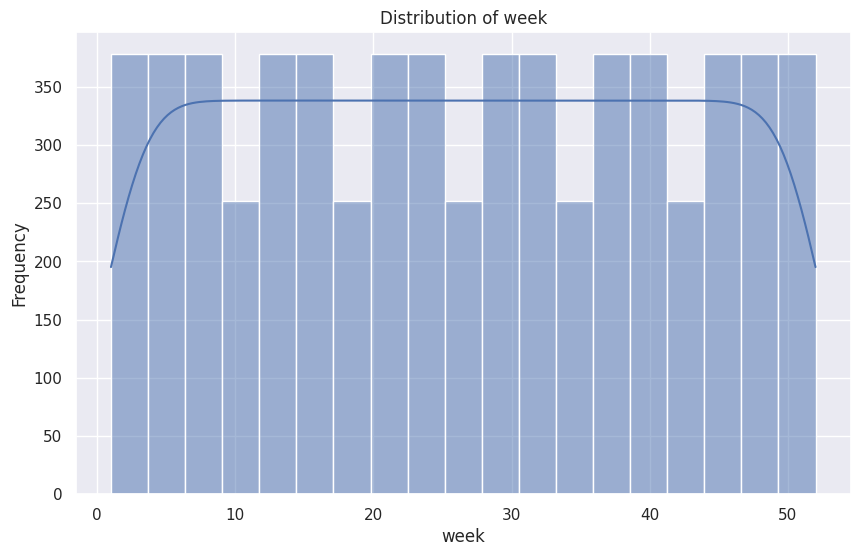

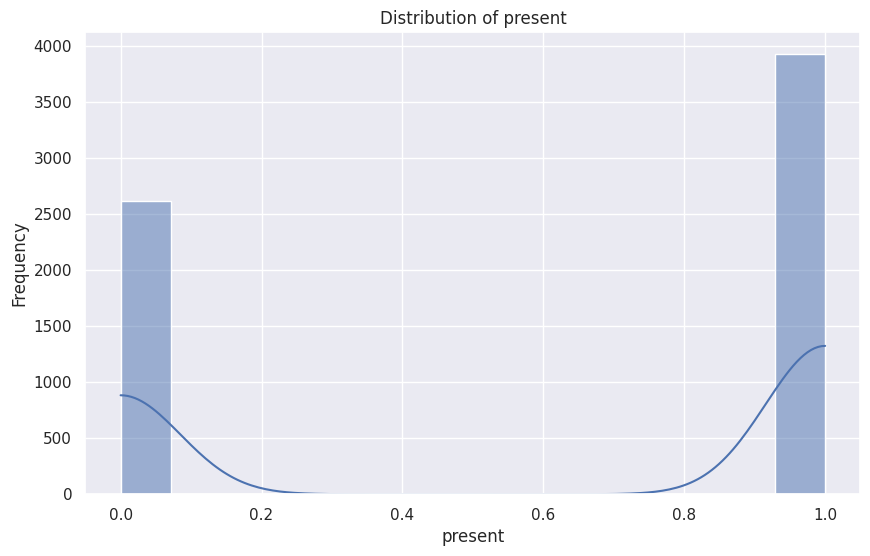

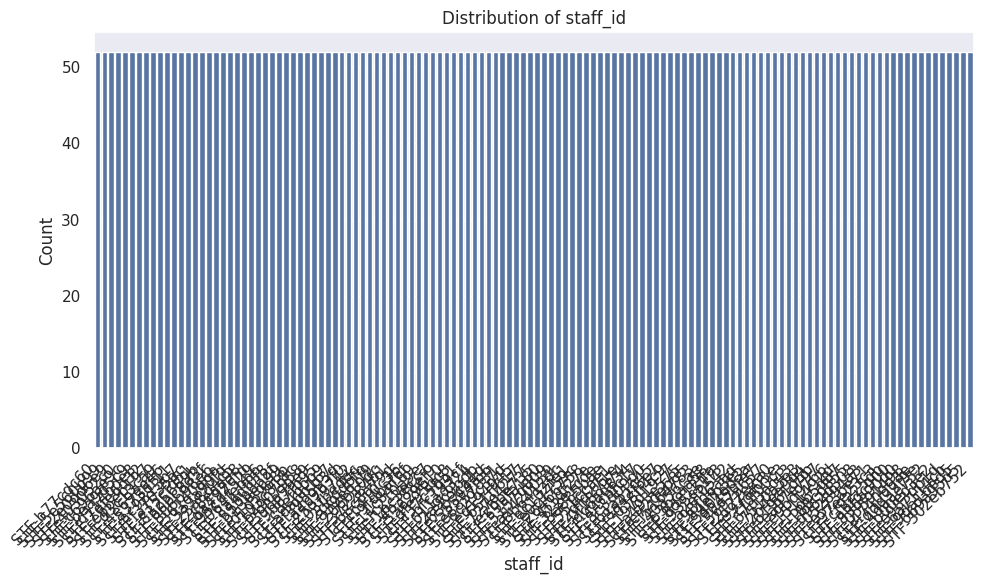

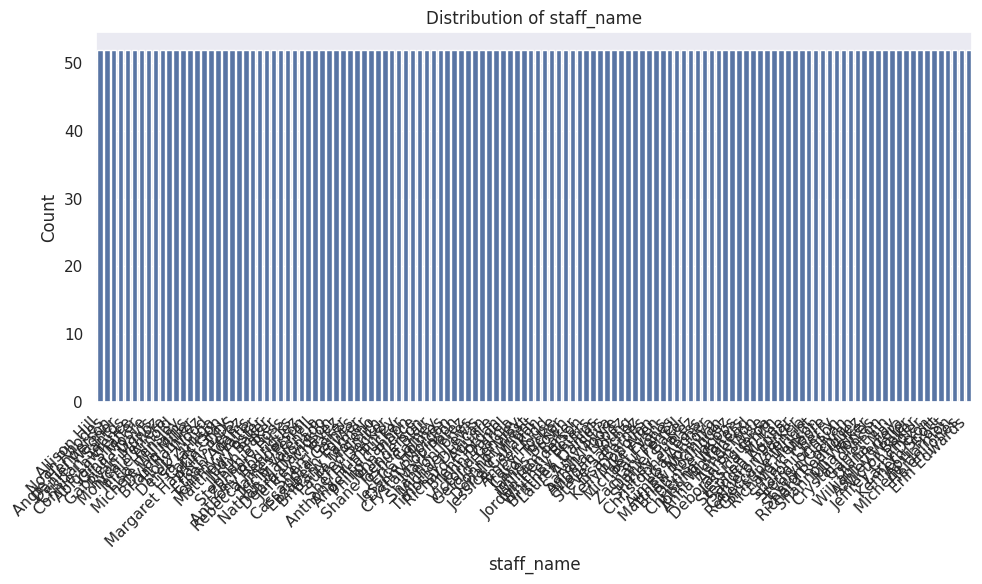

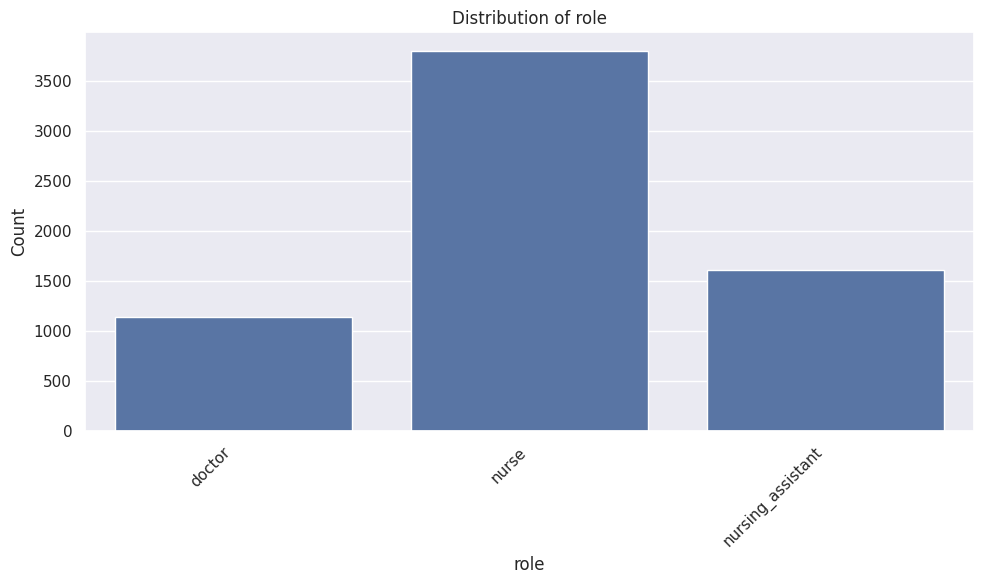

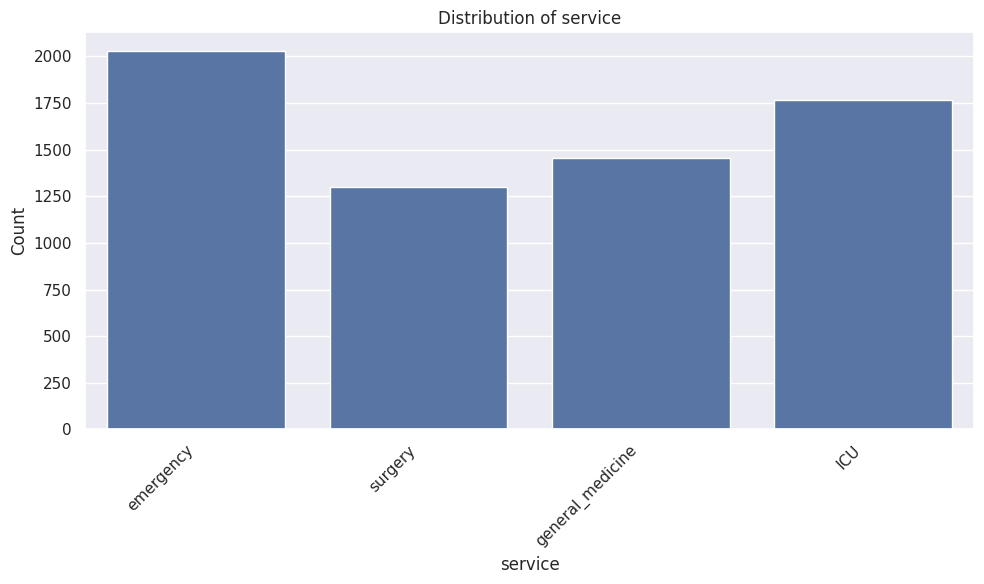

Value counts for staff_id:
staff_id
STF-b77cdc60    52
STF-5e560b99    52
STF-2e0dd6e9    52
STF-403052c0    52
STF-c696ae9c    52
                ..
STF-e983db1d    52
STF-6a7114cb    52
STF-9da1bed5    52
STF-669a95d5    52
STF-302eb752    52
Name: count, Length: 126, dtype: int64

Value counts for staff_name:
staff_name
Allison Hill       52
Noah Rhodes        52
Angie Henderson    52
Daniel Wagner      52
Cristian Santos    52
                   ..
Kenneth Scott      52
April Frost        52
Michelle Harmon    52
Helen Jones        52
Erin Edwards       52
Name: count, Length: 126, dtype: int64

Value counts for role:
role
nurse                3796
nursing_assistant    1612
doctor               1144
Name: count, dtype: int64

Value counts for service:
service
emergency           2028
ICU                 1768
general_medicine    1456
surgery             1300
Name: count, dtype: int64



In [52]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

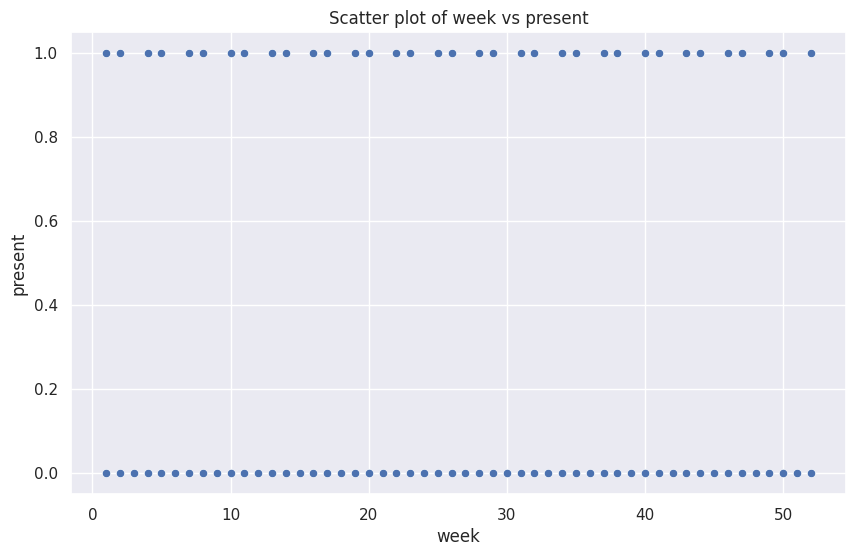

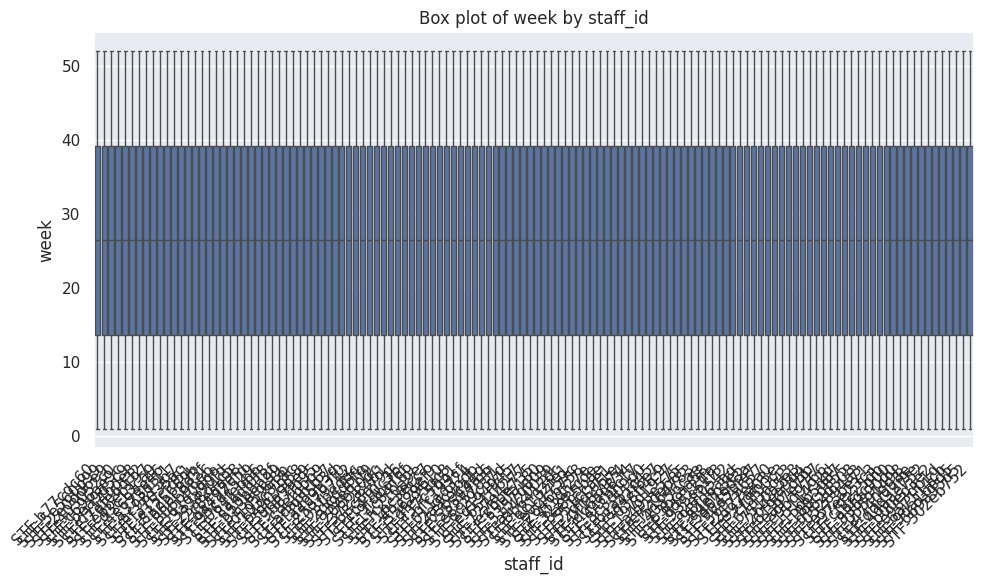

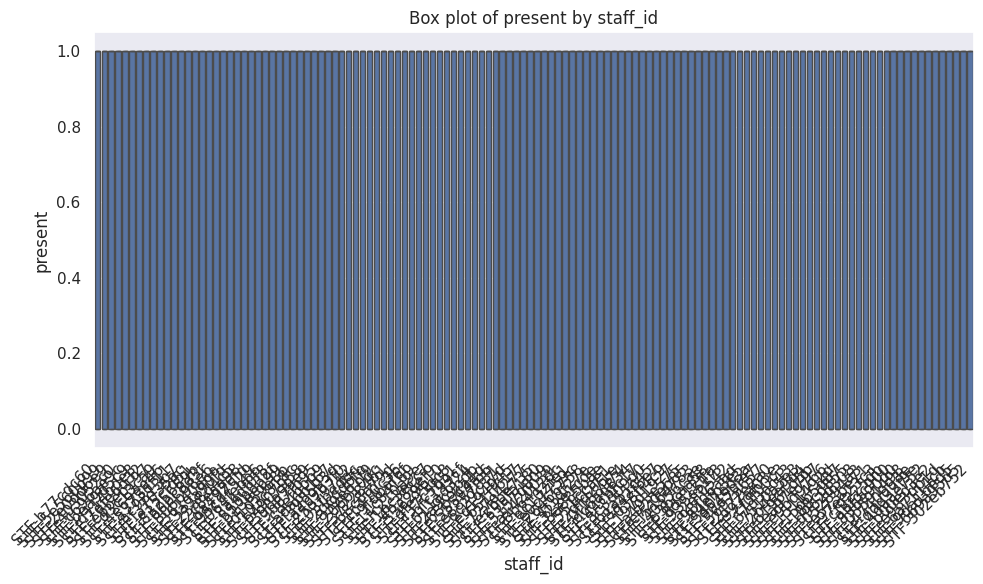

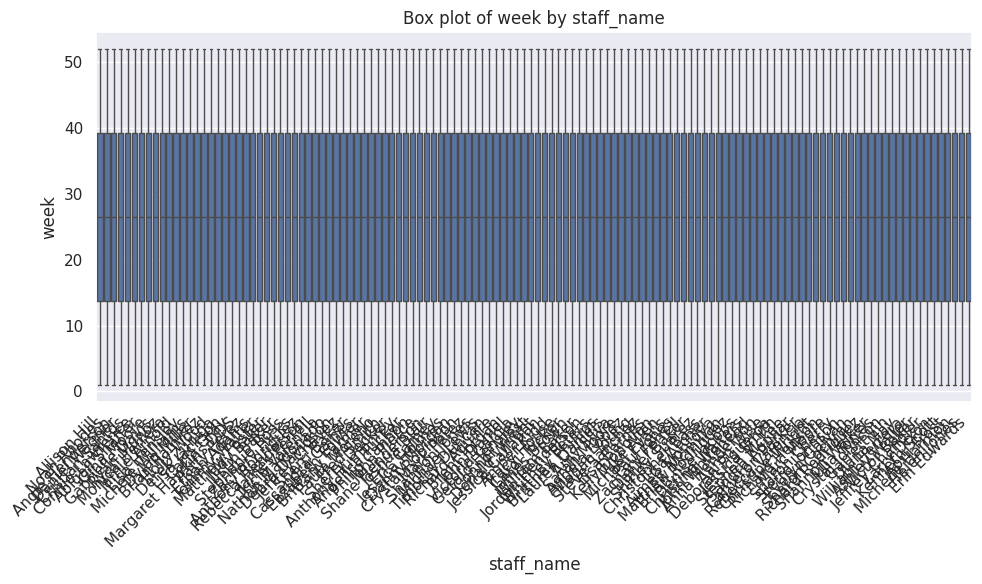

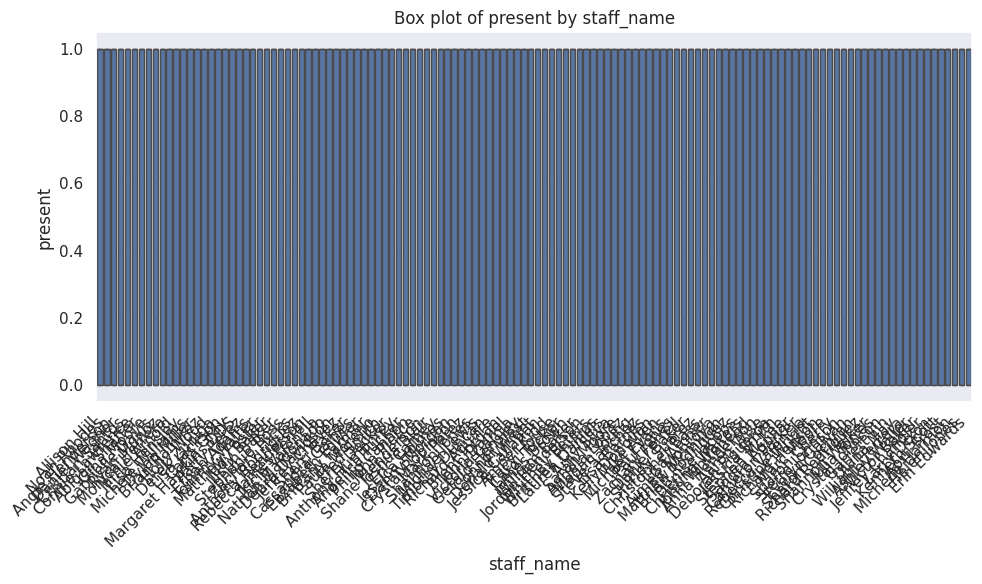

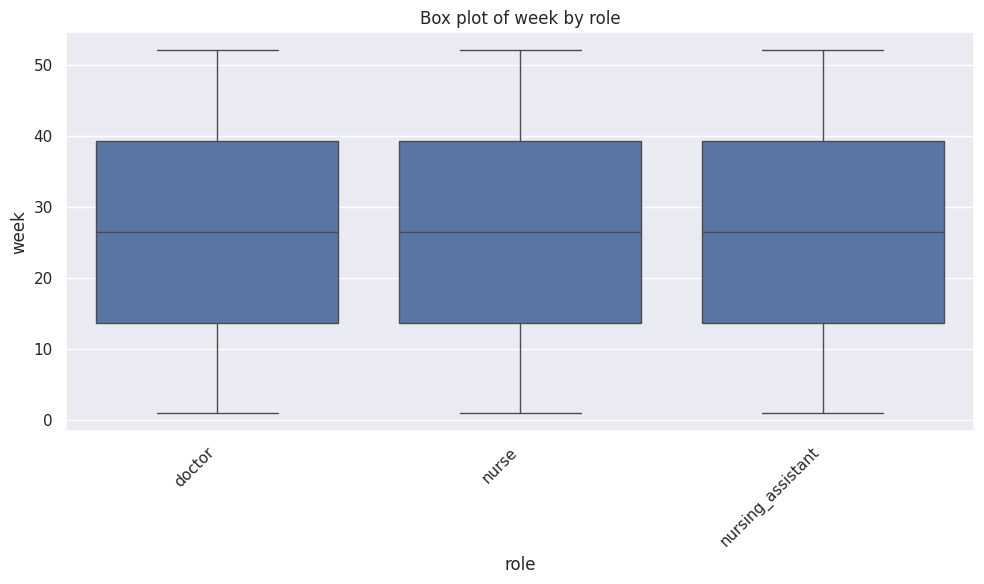

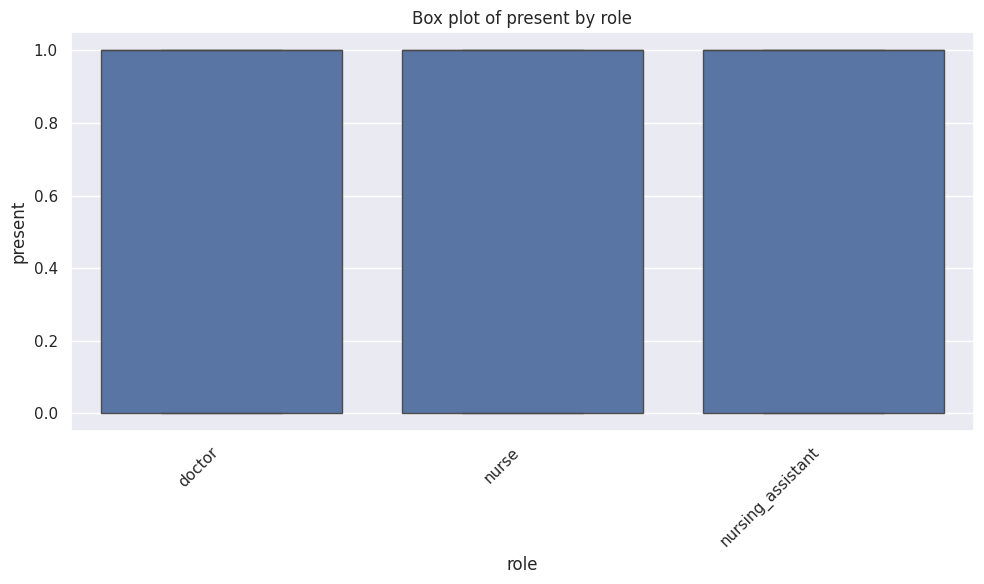

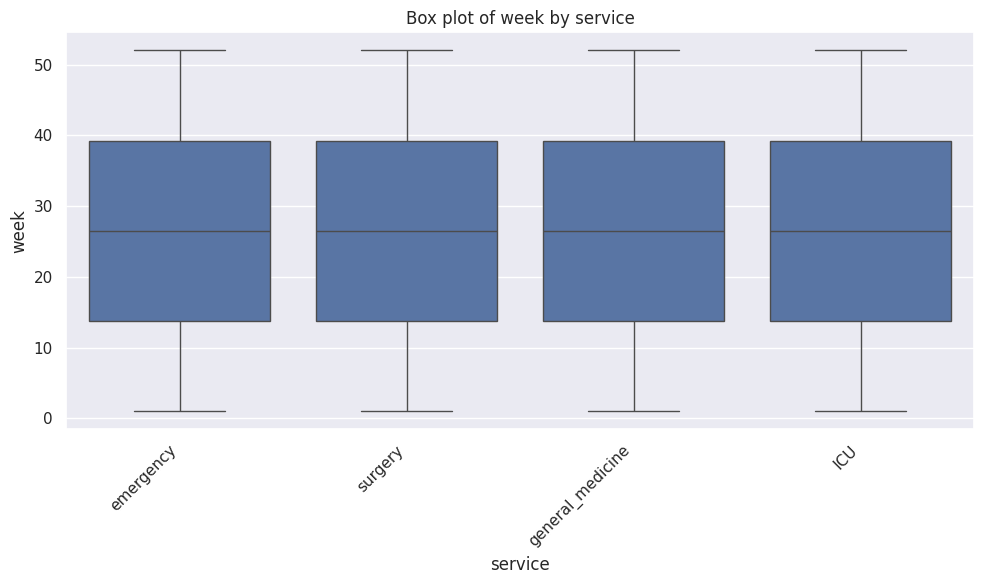

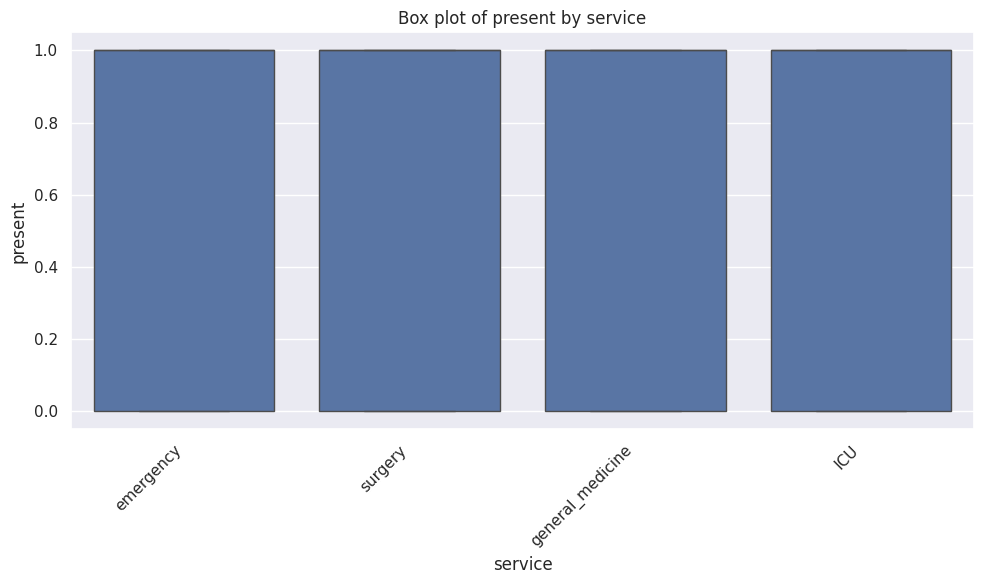

In [53]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

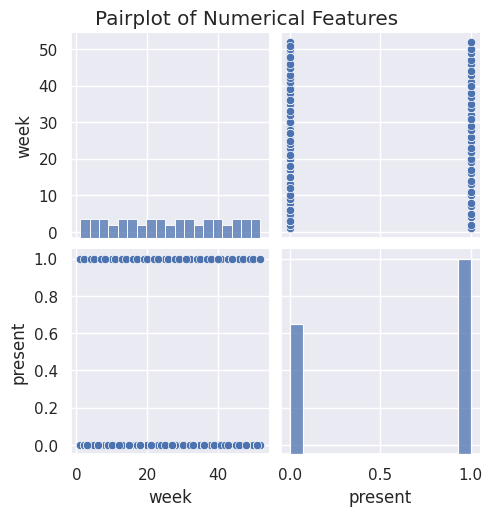

In [54]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

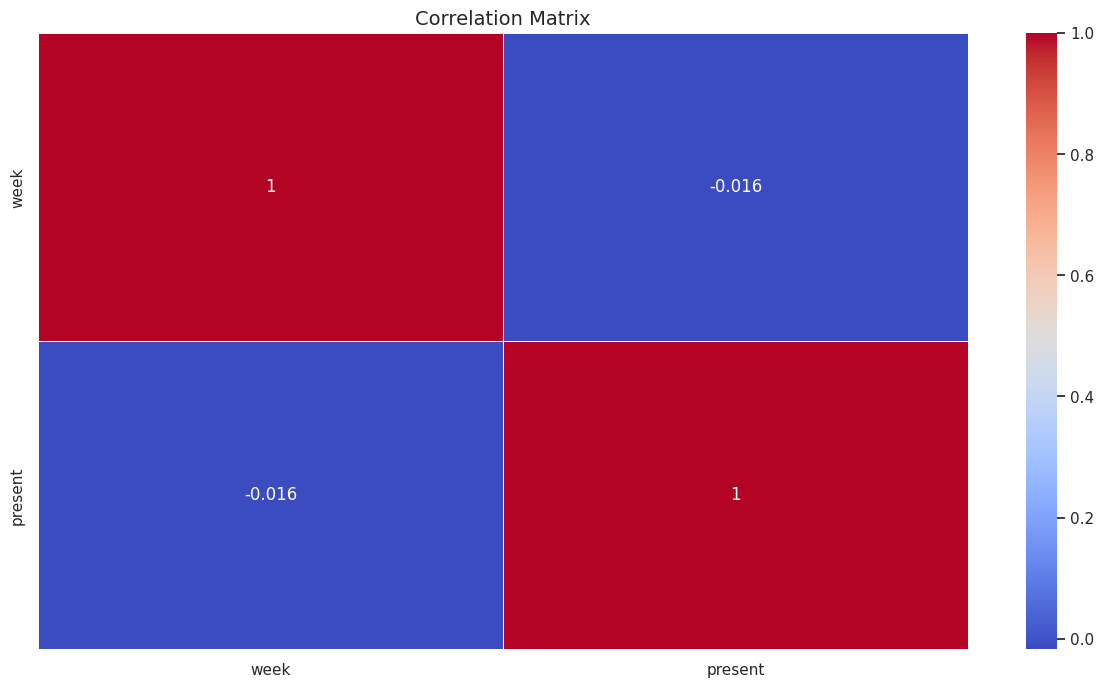

In [55]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you